In [ ]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from torchvision import transforms
from pathlib import Path
import math

from dataset import TextSegmentationDataset, IMAGE_SIZE, LARGE_SIZE
from utils import visualize_dataset_sample, demonstrate_image_preparation, demonstrate_model_with_1_image, test_model_metrics
from model import UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
LEARNING_RATE = 0.0001
TOTAL_STEPS = 32000
CHECKPOINT_INTERVAL = 100


In [48]:
IMAGE_DIR = Path("./DIV2K_train_LR_unknown/X2")

widths = []
heights = []

for img_path in IMAGE_DIR.iterdir():
    if img_path.is_file():
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

count = len(widths)

avg_width = sum(widths) / count
avg_height = sum(heights) / count

std_width = math.sqrt(sum((w - avg_width) ** 2 for w in widths) / count)
std_height = math.sqrt(sum((h - avg_height) ** 2 for h in heights) / count)

print(f"Number of images: {count}")
print(f"Average width: {avg_width:.2f} ± {std_width:.2f}")
print(f"Average height: {avg_height:.2f} ± {std_height:.2f}")


Number of images: 800
Average width: 985.75 ± 101.64
Average height: 717.59 ± 125.79


In [2]:
dataset = TextSegmentationDataset(
    root_dir="./DIV2K_train_LR_unknown/X2",
    augment=True
)
print(f"Dataset size: {len(dataset)}")
print(f"Image paths found: {len(dataset.image_paths)}")

Dataset size: 1000000000
Image paths found: 800


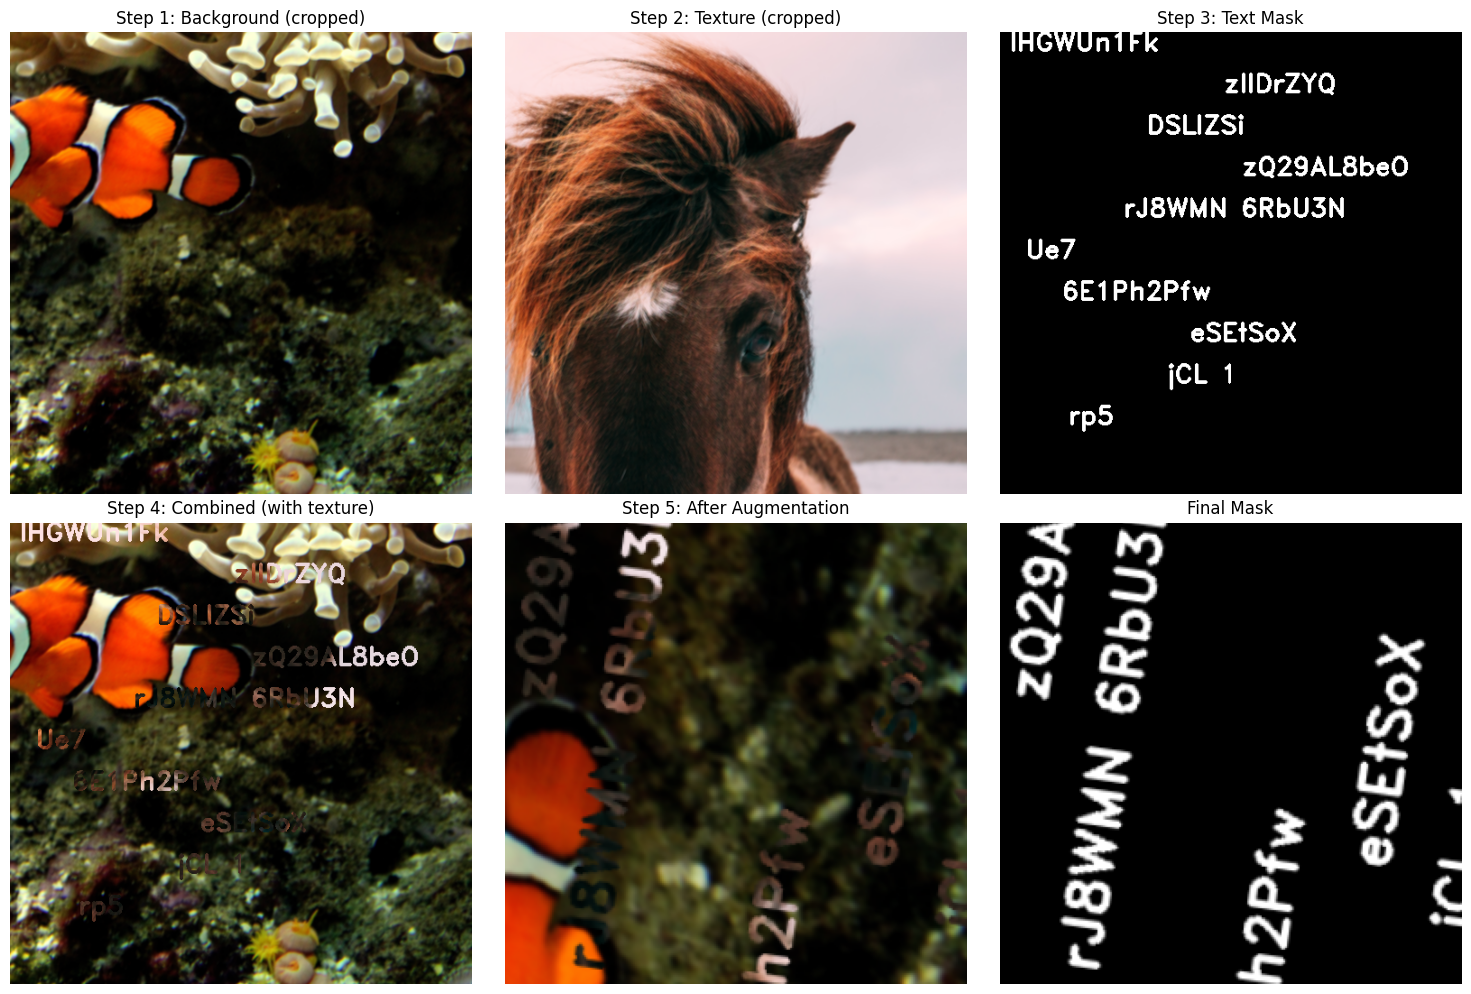

Font info: {'font_face': 2, 'font_scale': 0.9388379352586737, 'thickness': 2}


In [3]:
demonstrate_image_preparation(dataset)

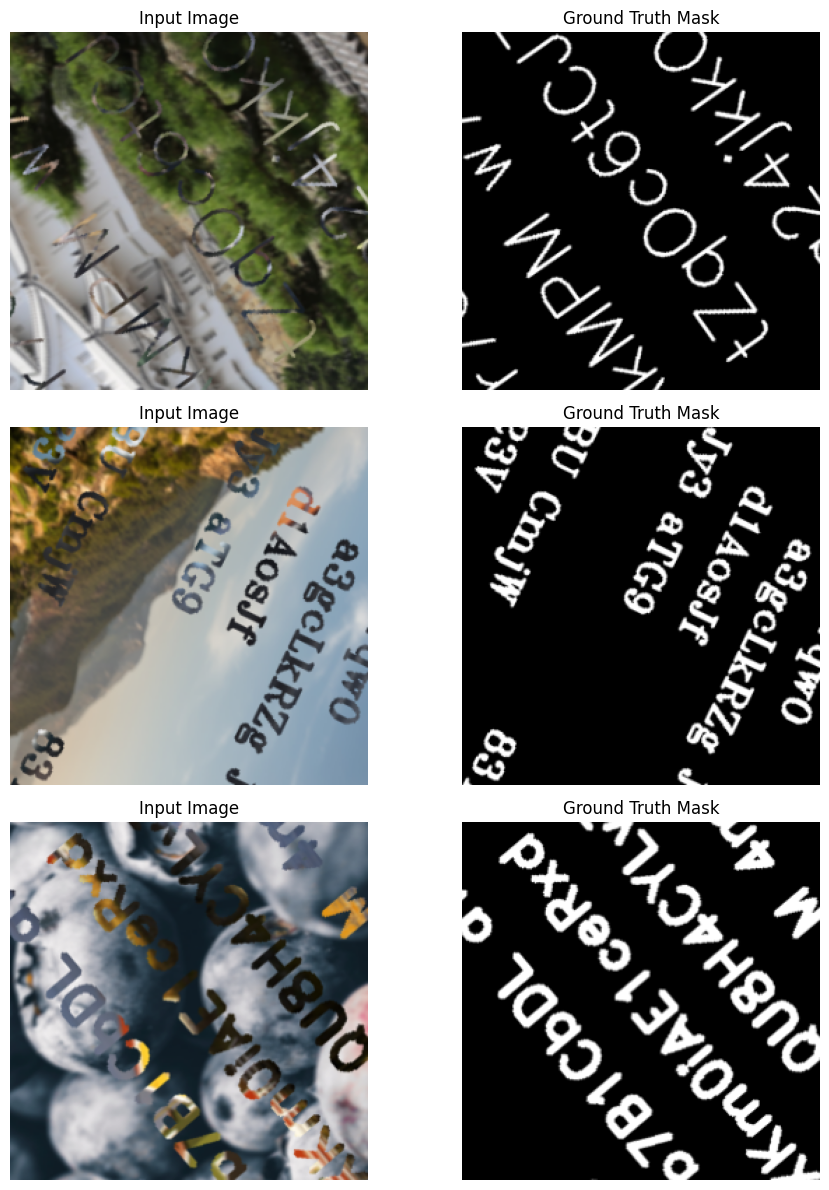

In [4]:
visualize_dataset_sample(dataset, idx=0, num_samples=3)

In [3]:
model = UNet().to(device)
print(model)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)



UNet(
  (down1): DownBlock(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu2): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, paddi

In [ ]:
CHECKPOINT_DIR = "./checkpoints"
RESUME_CHECKPOINT = "./checkpoints/model.pth"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

train_losses = []
step = 0

if RESUME_CHECKPOINT is not None and os.path.isfile(RESUME_CHECKPOINT):
    checkpoint = torch.load(RESUME_CHECKPOINT, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    train_losses = checkpoint.get("train_losses", [])
    step = checkpoint.get("step", 0)

model.train()
print("Starting training...")

while step < TOTAL_STEPS:
    batch_images = []
    batch_masks = []

    for _ in range(BATCH_SIZE):
        image, mask = dataset[0]
        batch_images.append(image)
        batch_masks.append(mask)

    images = torch.stack(batch_images).to(device)
    masks = torch.stack(batch_masks).to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, masks)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    step += 1

    if step % CHECKPOINT_INTERVAL == 0:
        checkpoint = {
            "step": step,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": train_losses,
        }
        torch.save(checkpoint, RESUME_CHECKPOINT)
        print(f"Step {step}/{TOTAL_STEPS} - Loss: {loss.item():.6f} - Checkpoint saved")

    if step % 10 == 0:
        print(f"Step {step}/{TOTAL_STEPS} - Loss: {loss.item():.6f}")

print("Training completed!")


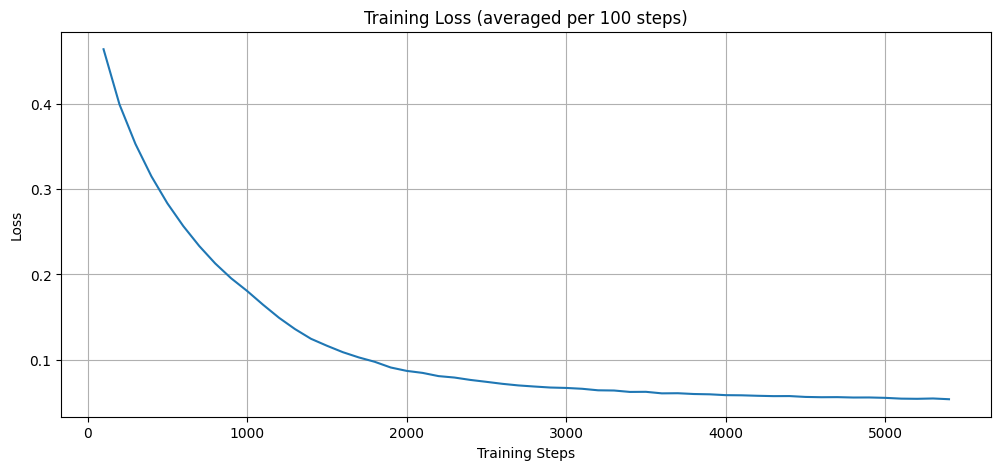

In [29]:
file_path = "./checkpoints/train_losses.txt"

with open(file_path, "r") as f:
    train_losses = [float(line.strip()) for line in f if line.strip()]

train_losses = np.array(train_losses)

N = 100
trim_len = len(train_losses) // N * N
train_losses = train_losses[:trim_len]

train_losses_avg = train_losses.reshape(-1, N).mean(axis=1)
steps_train = np.arange(N, len(train_losses) + 1, N)

plt.figure(figsize=(12, 5))
plt.plot(steps_train, train_losses_avg)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss (averaged per 100 steps)")
plt.grid(True)
plt.show()


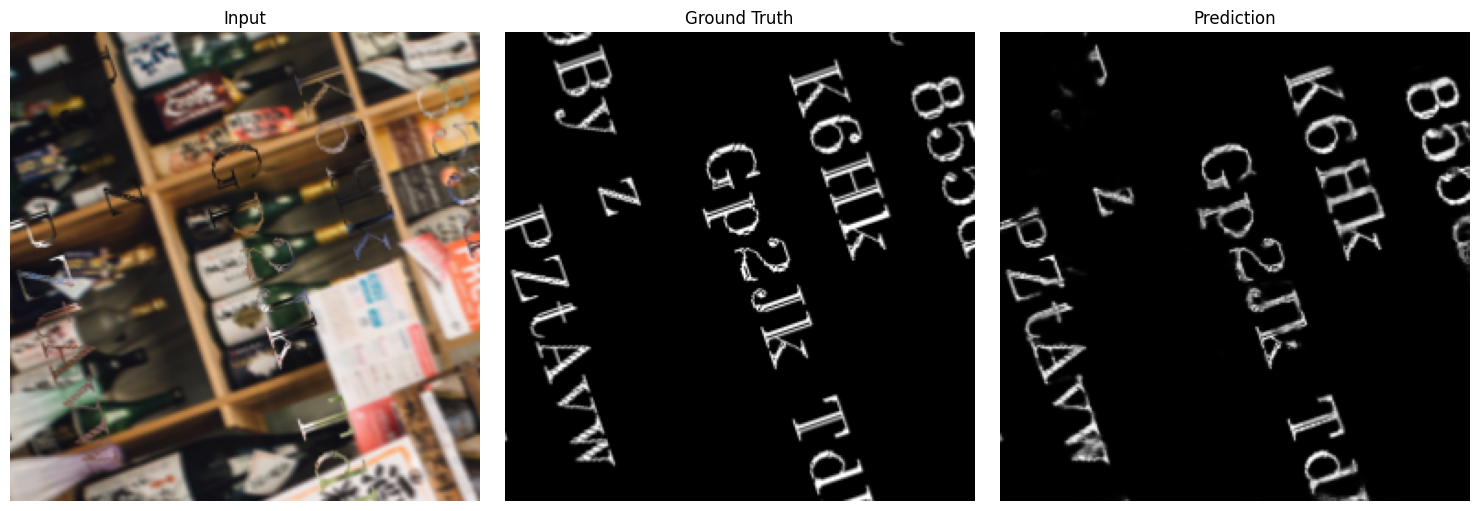

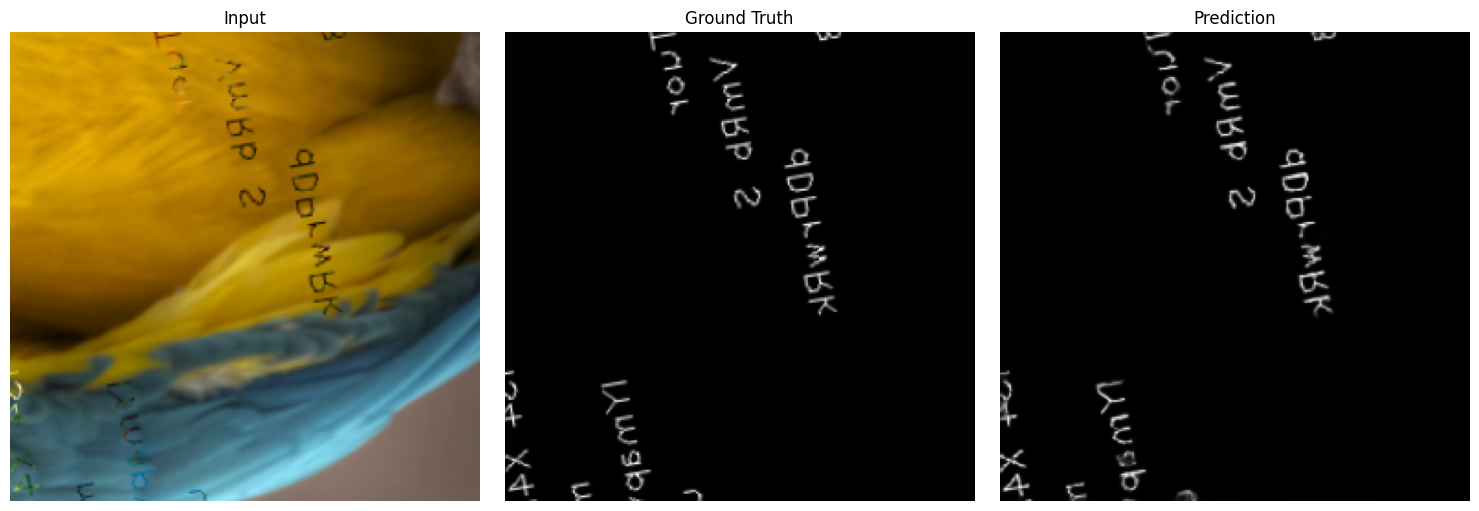

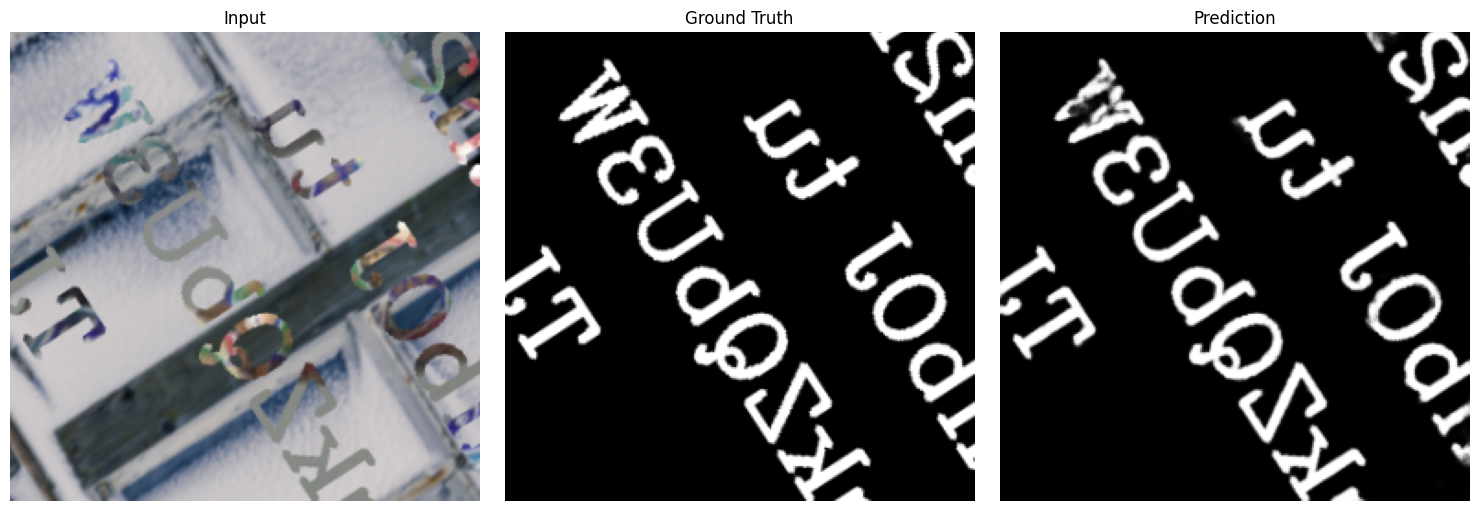

In [49]:
model1000 = UNet().to(device)
model1000.load_state_dict(torch.load("./checkpoints/model1000.pth", map_location=device))
model1000.eval()

model2000 = UNet().to(device)
checkpoint = torch.load("./checkpoints/model2000.pth", map_location=device)
model2000.load_state_dict(checkpoint["model_state_dict"])
model2000.eval()

model3240 = UNet().to(device)
checkpoint = torch.load("./checkpoints/model3240.pth", map_location=device)
model3240.load_state_dict(checkpoint["model_state_dict"])
model3240.eval()

model5320 = UNet().to(device)
checkpoint = torch.load("./checkpoints/model5320.pth", map_location=device)
model5320.load_state_dict(checkpoint["model_state_dict"])
model5320.eval()

demonstrate_model_with_1_image(model4320, dataset, device)
demonstrate_model_with_1_image(model4320, dataset, device)
demonstrate_model_with_1_image(model4320, dataset, device)


In [ ]:
test_model_metrics(model1000, dataset, device, num_test_images=100)
test_model_metrics(model2000, dataset, device, num_test_images=100)
test_model_metrics(model3240, dataset, device, num_test_images=100)
test_model_metrics(model5320, dataset, device, num_test_images=1000)


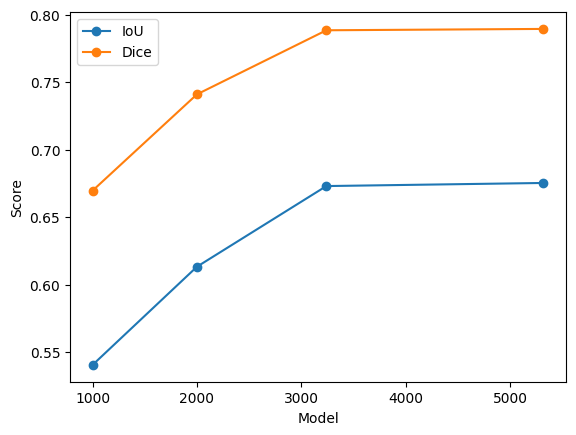

In [50]:

models = [1000, 2000, 3240, 5320]
iou = [0.5404, 0.6132, 0.6730, 0.6753]
dice = [0.6696, 0.7410, 0.7885, 0.7895]

plt.plot(models, iou, marker='o', label='IoU')
plt.plot(models, dice, marker='o', label='Dice')

plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.show()

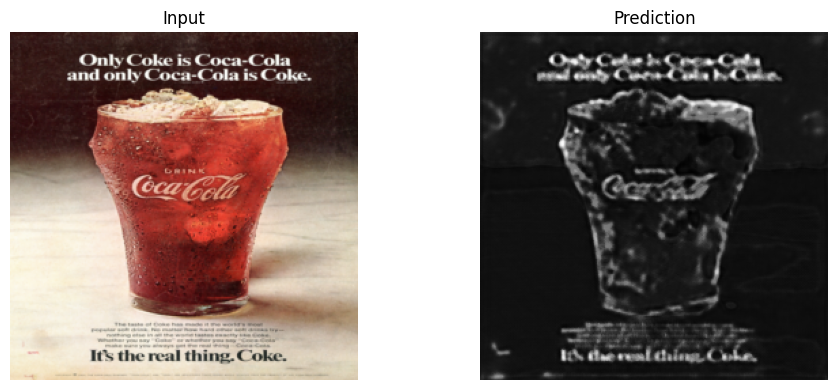

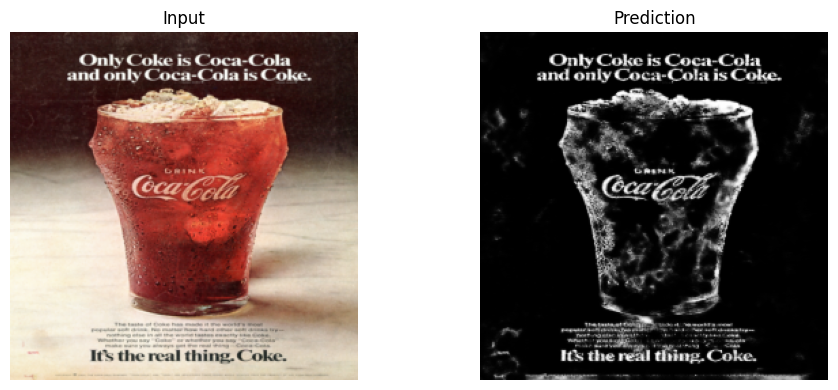

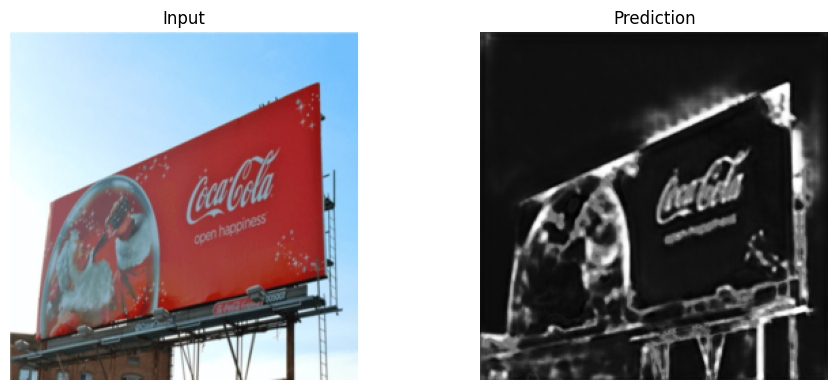

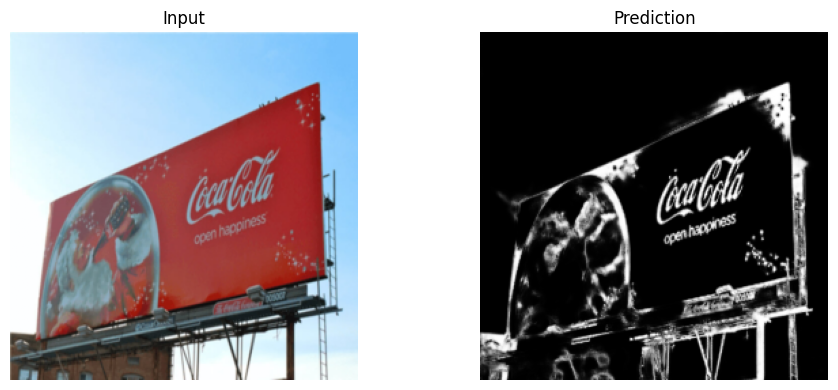

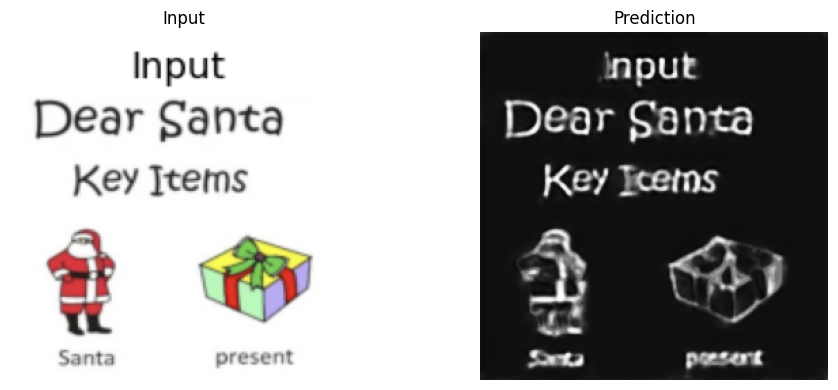

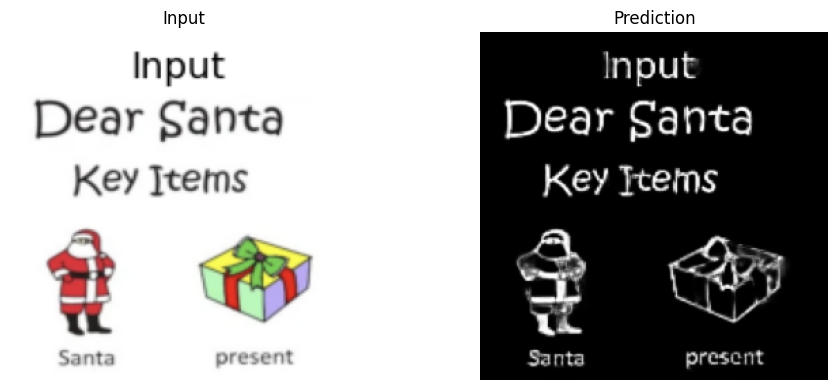

In [51]:
image1 = "./images/coca_cola.jpeg"
image2 = "./images/coca_cola_2.jpg"
image3 = "./images/santa.png"
demonstrate_model_with_1_image(model1000, dataset, device, image_path=image1)
demonstrate_model_with_1_image(model5320, dataset, device, image_path=image1)
demonstrate_model_with_1_image(model1000, dataset, device, image_path=image2)
demonstrate_model_with_1_image(model5320, dataset, device, image_path=image2)
demonstrate_model_with_1_image(model1000, dataset, device, image_path=image3)
demonstrate_model_with_1_image(model5320, dataset, device, image_path=image3)
